# ESMRMB 2026 analysis: ROI-variant comparison

This notebook reconstructs the quantitative panels from the ESMRMB 2026 abstract using the current `master.long.parquet` tables. Its scientific question is whether the derived microstructural observables are stable when the same diffusion data are summarized with different ROI definitions (`plain`, `erode1`, `sket1`, and future variants). Acquisition selection, physical constants, gradient correction, fitting models, bounds, and plotting rules are held fixed so that the ROI extraction is the intended changing factor.

Implemented analogues:

1. Paired OGSE signal fits and the resampled $\Delta M_{fit}(g)=M_{N=8}(g)-M_{N=4}(g)$ on one common corrected-gradient grid.
2. NOGSE-like contrast versus the historical Capiglioni center filter length $l_{cf}$, with $\tau_{f,\mathrm{peak}}(T_D)$ insets.
3. PGSE-derived macroscopic tortuosity $\alpha$ and NOGSE-derived transition time $\delta$ across regions.
4. $\delta$ versus $\alpha$ across regions, directions, subjects, and variants.

The complete dependency chain is

$$\text{master signals} \rightarrow \text{gradient correction} \rightarrow \text{paired signal fits} \rightarrow \text{common-grid resampling} \rightarrow \Delta M_{fit}(g) \rightarrow (l_{cf},\tau_{f,\mathrm{peak}}) \rightarrow \delta.$$

In parallel, projected PGSE diffusivities provide the macroscopic coefficient $\alpha$. The last panels compare $\alpha$ and $\delta$ across subjects, ROIs, directions, and extraction variants. The discovery step recognizes future analysis tags automatically. Dataset-specific choices remain in one configuration cell so the same workflow can be used for phantoms after their master tables are available.

This is an analysis and visualization notebook, not an ROI-generation notebook. It assumes that signal extraction, tensor rotation, gradient calibration, and alpha-summary generation have already completed for every selected variant.

## 1. Imports, provenance, and data model

Run the notebook from any directory inside the project. The helper below finds the project root without relying on a user-specific absolute path. All scientific calculations are implemented in `src/presentation_analysis/abstract_figures.py`; the notebook supplies configuration, displays intermediate QC, and exports reproducible artifacts.

The long master table is the source of truth. A signal row is identified by acquisition metadata (`subj`, `sheet`, $T_D$, $N$, source file and gradient step), spatial metadata (`roi`, rotated `direction`), statistic (`avg` or `std`), and processing provenance (`variant`, `analysis_tag`, `row_kind`). `signal_rotated` means the diffusion tensor and signal directions have already been expressed relative to the local ROI/fiber frame. The analysis never infers missing rows and never merges subjects or acquisition sheets.

Main units used below: $T_D$, $\tau_c$, $\tau_f$, $c$, and $\delta$ are in ms; gradient strength is in mT/m; $D_0$ is stored in m$^2$/ms; and the Capiglioni filter length $l_{cf}=\sqrt{D_0\tau_f}$ is displayed in $\mu$m. Normalized signal and contrast are dimensionless.

In [21]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'Data-BIDS').is_dir() and (candidate / 'repos' / 'signal_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the Project-Balseiro-Microstructure root.')


PROJECT_ROOT = find_project_root()
REPO_ROOT = PROJECT_ROOT / 'repos' / 'signal_analysis'
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Reload local helpers so Run All also picks up code changes in an existing kernel.
import presentation_analysis.abstract_figures as _abstract_figures
import presentation_analysis as _presentation_analysis
importlib.reload(_abstract_figures)
importlib.reload(_presentation_analysis)

from presentation_analysis import (
    CC_ROIS,
    aggregate_alpha,
    build_resampled_contrasts,
    compare_with_reference,
    compare_with_reference_metrics,
    discover_analysis_runs,
    export_all_contrast_lcf_panels,
    export_all_signal_contrast_panels,
    fit_tc_pseudohuber,
    load_alpha_summaries,
    load_masters,
    master_qc_summary,
    merge_alpha_delta,
    normalize_alpha_to_internal_reference,
    plot_alpha_delta_scatter,
    plot_contrast_lcf_grid,
    plot_metric_comparison,
    plot_signal_contrast_example,
    save_figure_formats,
    summarize_contrast_shape,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 80)
PROJECT_ROOT

PosixPath('/mnt/d/GitHub/Project-Balseiro-Microstructure')

## 2. Configuration

The first lines under **Quick selection** are normally the only ones that need editing. Choose `DATASET = 'brains'` or `DATASET = 'phantoms'`, then set `SUBJECTS_OVERRIDE`, `ROI_OVERRIDE`, and `DIRECTION_OVERRIDE`. Use a Python list even for one value, for example `['20220610P']`, `['fiber1']`, or `['long']`; use `None` to include every value allowed by the dataset profile. `SHEETS_OVERRIDE` can isolate an acquisition when one subject has several sheets.

For phantoms, selecting exactly one known subject also selects its processed source automatically: `20220610P` uses `den_gr--manual`, whereas `20260706P` uses `den_gr-topup--manual`. `DWI_LEVEL_OVERRIDE` is therefore normally left as `None`. `EXAMPLE_*` and `EXAMPLE_TD_MS` change only the detailed example panels; they do not filter the complete analysis. `VARIANTS = None` discovers current and future ROI variants automatically.

The reference diffusivity $D_0$ is a physical prior used by the restricted-signal model and by the gradient-to-length transformation; it is not refitted independently for every ROI in this notebook. Consequently, brain and phantom values must remain explicit and should be reviewed before the phantom analysis is finalized. The $N=8$ and $N=4$ selection defines the two encoding waveforms whose difference is studied. `GRADIENT_COLUMN = 'g'` is the project default because it preserves the recorded, non-equally-spaced b-value sampling; use `g_thorsten` only for an explicit legacy sensitivity analysis.

`SAVE_OUTPUTS` controls persistent tables and presentation figures. Every saved figure is written in both PNG and PDF. `EXPORT_ALL_SIGNAL_CONTRAST_PANELS` controls the exhaustive Section 6 gallery. `EXPORT_ALL_CONTRAST_LCF_PANELS` creates a Figure-02-style image for every selected subject and ROI, with directions in columns and every available $T_D$ as a colored curve. Both are enabled by default.

In [22]:
# -----------------------------------------------------------------------------
# QUICK SELECTION: edit this block first, then use Kernel > Restart & Run All.
# -----------------------------------------------------------------------------
DATASET = 'brains'  # 'brains' or 'phantoms'
#Examples: ['20220610P'], ['20260706P'], ['ADBN'], ['ADBN', 'ARVE', 'BRAIN', 'LUDG', 'MBBL', 'SNVN'], or None for all subjects
SUBJECTS_OVERRIDE = None
# Optional acquisition-sheet filter, useful when one brain subject has several scans
SHEETS_OVERRIDE = None            # e.g. ['20230623_BRAIN-4']
# Lists filter the complete analysis; None uses all defaults/available values
ROI_OVERRIDE = None               # phantom e.g. ['fiber1']; brain e.g. ['PostCC']
DIRECTION_OVERRIDE = None         # e.g. ['long'], ['tra'], or ['long', 'tra']

# One detailed signal/contrast panel (these settings do NOT filter the analysis)
EXAMPLE_SUBJECT_OVERRIDE = None   # None uses the selected subject when it is unique
EXAMPLE_ROI_OVERRIDE = None       # e.g. 'fiber1' or 'PostCC' (a string, not a list)
EXAMPLE_DIRECTION_OVERRIDE = None # e.g. 'long' or 'tra'
EXAMPLE_TD_MS = 143.4             # old phantom also has 142.5 ms; nearest value is used

# Dataset profiles: acquisition physics and default selections. Usually do not edit.
DATASET_PROFILES = {
    'brains': {
        'dwi_level': 'den_gr-topup',
        'd0_m2_ms': 3.2e-12,     # 0.0032 mm2/s
        'rois': list(CC_ROIS),
        'directions': ['long', 'tra'],
        'example_subject': 'ADBN',
        'example_roi': 'PostCC',
        'example_direction': 'long',
    },
    'phantoms': {
        'dwi_level': 'den_gr-topup',
        'd0_m2_ms': 2.3e-12,     # 0.0023 mm2/s
        'rois': None,               # None uses every ROI/sample found in the phantom master
        'directions': None,         # None prefers long/tra, then uses every available direction
        'example_subject': '20220610P',
        'example_roi': None,
        'example_direction': None,
    },
}

# Advanced data-source selection
SEQUENCE = 'ogse'
# Leave None: the notebook maps 20220610P -> den_gr and 20260706P -> den_gr-topup.
DWI_LEVEL_OVERRIDE = None          # force only when auditing a specific processing level
VARIANTS = None                   # brains e.g. ['plain'] or ['plain', 'erode1', 'sket1']
REFERENCE_VARIANT = None           # None prefers plain; phantoms use manual

# Contrast definition from the abstract
N_HIGH = 8
N_LOW = 4
# Use the gradient derived from each recorded b-value. This preserves non-equally-spaced
# acquisitions such as ADBN, ARVE, SNVN, and 20260706P. Set 'g_thorsten' only to
# reproduce the legacy equally-spaced-axis analysis.
GRADIENT_COLUMN = 'g'
APPLY_GRADIENT_CORRECTION = True
RESAMPLE_GRID_SIZE = 1000
SIGNAL_TC_BOUNDS_MS = (0.1, 10000.0)
RICIAN_C_BOUNDS = (0.0, 2.0)
SIGNAL_TC_MODE = 'separate'         # Flexible curve construction; not a physical two-tc interpretation

# Example-panel display limits
LCF_LIMITS_UM = (2.5, 11.0)  # Historical Capiglioni/abstract axis
TD_COLOR_TOLERANCE_MS = 8.0  # Includes both historical and current acquisition times

# Pseudo-Huber configuration used in the abstract analysis
EXCLUDE_TD_MS = (76.0,)
TD_RANGE_MS = (50.0, 250.0)
C_BOUNDS_MS = (0.0, 10.0)
DELTA_BOUNDS_MS = (1e-6, 10000.0)

# Transparent display-only QC. All fits remain in the exported audit tables.
MIN_PSEUDOHUBER_R2_FOR_SUMMARY = 0.50
EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY = True

# Exhaustive Section 6 export: one panel per subject/sheet/ROI/direction/TD combination.
EXPORT_ALL_SIGNAL_CONTRAST_PANELS = True
# Figure-02 gallery: one contrast-vs-filtered-length image per subject and ROI.
EXPORT_ALL_CONTRAST_LCF_PANELS = True
CLEAN_BATCH_PANEL_DIR = True       # Remove stale PNG/PDF files and the manifest inside each gallery
BATCH_PANEL_DPI = 180             # Lower than the presentation figures to control disk usage
BATCH_PROGRESS_EVERY = 25

SAVE_OUTPUTS = True

# Known phantom subjects use different processed derivatives.
PHANTOM_DWI_LEVEL_BY_SUBJECT = {
    '20220610P': 'den_gr',
    '20260706P': 'den_gr-topup',
}

def selection_list(value):
    if value is None:
        return None
    return [value] if isinstance(value, str) else list(value)

SELECTED_SUBJECTS = selection_list(SUBJECTS_OVERRIDE)
SELECTED_SHEETS = selection_list(SHEETS_OVERRIDE)
if DATASET not in DATASET_PROFILES:
    raise ValueError(f'Unknown DATASET={DATASET!r}; choose one of {list(DATASET_PROFILES)}.')
PROFILE = DATASET_PROFILES[DATASET]
if DWI_LEVEL_OVERRIDE is not None:
    DWI_LEVEL = DWI_LEVEL_OVERRIDE
elif DATASET == 'phantoms' and SELECTED_SUBJECTS is not None and len(SELECTED_SUBJECTS) == 1:
    DWI_LEVEL = PHANTOM_DWI_LEVEL_BY_SUBJECT.get(SELECTED_SUBJECTS[0], PROFILE['dwi_level'])
else:
    DWI_LEVEL = PROFILE['dwi_level']
D0_REFERENCE_M2_MS = PROFILE['d0_m2_ms']
OUTPUT_DIR = (
    REPO_ROOT / 'notebooks' / 'outputs' / 'esmrmb_variant_comparison' / DATASET / DWI_LEVEL
)
OUTPUT_DIR

PosixPath('/mnt/d/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup')

## 3. Discover variants and audit comparability

The analysis tag is parsed as `<DWI level>--<ROI variant>`. Newly created variants appear automatically when `VARIANTS` is `None`. Every table is loaded with its variant and dataset provenance attached before concatenation.

For the current corpus-callosum analysis, `plain` is the original labeled CC mask, `erode1` erodes the whole CC by one voxel and then restores the surviving original labels, and `sket1` is the CC skeleton dilated by one voxel and clipped to the original CC. Erosion reduces boundary partial volume but can delete thin subregions; the skeletonized band emphasizes the medial core but samples fewer and spatially different voxels. Therefore agreement across variants supports robustness to ROI geometry, whereas disagreement can reflect partial volume, SNR/voxel-count changes, or true spatial heterogeneity—it is not automatically an error in one method. Future variant names are treated as new provenance levels; their biological interpretation must come from the segmentation procedure that created them.

A fair segmentation comparison requires more than a similar total row count. Coverage is therefore compared on the complete logical signal key. `missing_rows` reports reference observations that cannot be matched in a candidate variant, while `extra_rows` reports the reverse. A missing ROI can be a legitimate consequence of erosion or skeletonization, but it reduces the paired sample and must remain visible. Exact or logical duplicates indicate an ingestion problem and should be resolved upstream.

Later group summaries use only matched subject/ROI/direction keys. No signal, fit, ROI, or subject is imputed to make variants appear balanced.

In [23]:
runs = discover_analysis_runs(
    PROJECT_ROOT,
    dataset=DATASET,
    sequence=SEQUENCE,
    dwi_level=DWI_LEVEL,
)
available_variants = runs['variant'].tolist()
if VARIANTS is None:
    preferred_order = ['plain', 'erode1', 'sket1']
    selected_variants = [v for v in preferred_order if v in available_variants]
    selected_variants += [v for v in available_variants if v not in selected_variants]
else:
    selected_variants = list(VARIANTS)
if REFERENCE_VARIANT is None:
    REFERENCE_VARIANT = 'plain' if 'plain' in selected_variants else selected_variants[0]
if REFERENCE_VARIANT not in selected_variants:
    raise ValueError(f'Reference variant {REFERENCE_VARIANT!r} is not selected.')

display(runs[['dwi_level', 'variant', 'dataset', 'master_path']])
print('Selected variants:', selected_variants)

,dwi_level,variant,dataset,master_path
0,den_gr-topup,erode1,brains,/mnt/d/GitHub/Project-Balseiro-Microstructure/...
1,den_gr-topup,plain,brains,/mnt/d/GitHub/Project-Balseiro-Microstructure/...
2,den_gr-topup,sket1,brains,/mnt/d/GitHub/Project-Balseiro-Microstructure/...


Selected variants: ['plain', 'erode1', 'sket1']


In [24]:
masters = load_masters(runs, selected_variants)
alpha_raw = load_alpha_summaries(
    runs, selected_variants, reference_d0_m2_ms=D0_REFERENCE_M2_MS
)

# Filter complete tables, not only the example plot. Fail early on misspelled values.
for column, requested in [('subj', SELECTED_SUBJECTS), ('sheet', SELECTED_SHEETS)]:
    if requested is None:
        continue
    available = sorted(masters[column].dropna().astype(str).unique())
    missing = sorted(set(requested) - set(available))
    if missing:
        raise ValueError(
            f'{column} selection {missing} is unavailable for DATASET={DATASET!r}, '
            f'DWI_LEVEL={DWI_LEVEL!r}. Available values: {available}'
        )
    masters = masters[masters[column].astype(str).isin(requested)].copy()
    if column in alpha_raw.columns:
        alpha_raw = alpha_raw[alpha_raw[column].astype(str).isin(requested)].copy()
alpha_subject = aggregate_alpha(alpha_raw)

# Resolve analysis dimensions from the profile and the loaded master table.
rotated = masters.loc[masters['row_kind'].eq('signal_rotated')].copy()
available_subjects = sorted(rotated['subj'].dropna().astype(str).unique())
available_sheets = sorted(rotated['sheet'].dropna().astype(str).unique())
available_rois = sorted(rotated['roi'].dropna().astype(str).unique())
available_directions = sorted(rotated['direction'].dropna().astype(str).unique())
available_td_ms = sorted(pd.to_numeric(rotated['td_ms'], errors='coerce').dropna().unique())
requested_rois = ROI_OVERRIDE if ROI_OVERRIDE is not None else PROFILE['rois']
requested_directions = (
    DIRECTION_OVERRIDE if DIRECTION_OVERRIDE is not None else PROFILE['directions']
)
analysis_rois = (
    available_rois
    if requested_rois is None
    else [roi for roi in requested_rois if roi in available_rois]
)
if requested_directions is None:
    preferred_directions = [d for d in ['long', 'tra'] if d in available_directions]
    analysis_directions = preferred_directions or available_directions
else:
    analysis_directions = [d for d in requested_directions if d in available_directions]
if not analysis_rois or not analysis_directions:
    raise ValueError(
        f'No usable dimensions. Available ROIs={available_rois}; directions={available_directions}.'
    )

profile_example_subject = PROFILE['example_subject']
profile_example_roi = PROFILE['example_roi']
profile_example_direction = PROFILE['example_direction']
EXAMPLE_SUBJECT = (
    EXAMPLE_SUBJECT_OVERRIDE
    or (SELECTED_SUBJECTS[0] if SELECTED_SUBJECTS is not None and len(SELECTED_SUBJECTS) == 1 else None)
    or (profile_example_subject if profile_example_subject in available_subjects else None)
)
EXAMPLE_ROI = (
    EXAMPLE_ROI_OVERRIDE
    or (profile_example_roi if profile_example_roi in available_rois else None)
)
EXAMPLE_DIRECTION = (
    EXAMPLE_DIRECTION_OVERRIDE
    or (profile_example_direction if profile_example_direction in available_directions else None)
)

qc = master_qc_summary(masters)
coverage, missing_rows = compare_with_reference(
    masters,
    reference_variant=REFERENCE_VARIANT,
    row_kind='signal_rotated',
)
display(qc)
display(coverage)
print('Subjects:', available_subjects)
print('Sheets:', available_sheets)
print('Analysis ROIs:', analysis_rois)
print('Analysis directions:', analysis_directions)
print('Diffusion times [ms]:', available_td_ms)
print(
    'Requested example:',
    EXAMPLE_SUBJECT or 'auto',
    EXAMPLE_ROI or 'auto',
    EXAMPLE_DIRECTION or 'auto',
    EXAMPLE_TD_MS,
)

,variant,rows,signal_rows,rotated_rows,subjects,sheets,sources,exact_duplicates,logical_duplicates
0,plain,275520,217920,57600,6,10,92,0,0
1,erode1,275520,217920,57600,6,10,92,0,0
2,sket1,273582,216390,57192,6,10,92,0,0


,variant,reference,reference_rows,matched_rows,missing_rows,extra_rows,coverage_percent
0,plain,plain,57600,57600,0,0,100.000000
1,erode1,plain,57600,57600,0,0,100.000000
2,sket1,plain,57600,57192,408,0,99.291667


Subjects: ['ADBN', 'ARVE', 'BRAIN', 'LUDG', 'MBBL', 'SNVN']
Sheets: ['20220622_BRAIN', '20230619_BRAIN-3', '20230623_BRAIN-4', '20230623_LUDG-2', '20230629_MBBL-2', '20230630_MBBL-3', '20230710_LUDG-3', '20260710_ADBN-1', '20260710_ARVE-1', '20260710_SNVN-1']
Analysis ROIs: ['AntCC', 'MidAntCC', 'CentralCC', 'MidPostCC', 'PostCC']
Analysis directions: ['long', 'tra']
Diffusion times [ms]: [np.float64(76.0), np.float64(90.0), np.float64(120.0), np.float64(143.4), np.float64(210.0)]
Requested example: ADBN PostCC long 143.4


,variant,subj,roi,direction,missing_rows
0,sket1,ARVE,AntCC,eig1,18
1,sket1,ARVE,AntCC,eig2,18
2,sket1,ARVE,AntCC,eig3,18
3,sket1,ARVE,AntCC,long,18
4,sket1,ARVE,AntCC,tra,18
5,sket1,ARVE,AntCC,x,18
6,sket1,ARVE,AntCC,y,18
7,sket1,ARVE,AntCC,z,18
8,sket1,BRAIN,MidPostCC,eig1,33
9,sket1,BRAIN,MidPostCC,eig2,33


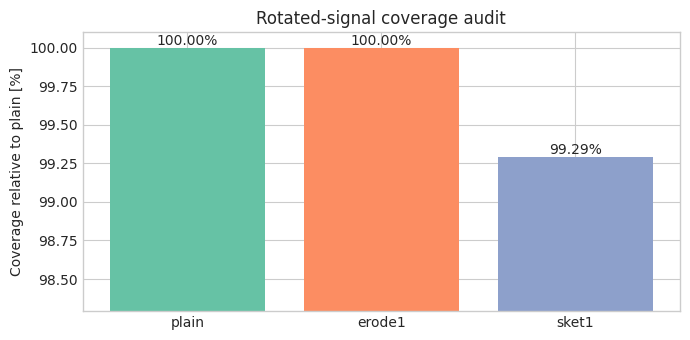

In [25]:
if missing_rows.empty:
    print('Every selected variant has the same rotated-row coverage as the reference.')
else:
    missing_summary = (
        missing_rows.groupby(['variant', 'subj', 'roi', 'direction'], as_index=False)
        .size()
        .rename(columns={'size': 'missing_rows'})
    )
    display(missing_summary)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(coverage['variant'], coverage['coverage_percent'], color=plt.cm.Set2.colors[:len(coverage)])
ax.set_ylim(max(0, coverage['coverage_percent'].min() - 1), 100.1)
ax.set_ylabel(f'Coverage relative to {REFERENCE_VARIANT} [%]')
ax.set_title('Rotated-signal coverage audit')
for index, value in enumerate(coverage['coverage_percent']):
    ax.text(index, value, f'{value:.2f}%', ha='center', va='bottom')
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_figure_formats(fig, OUTPUT_DIR / '00_coverage_audit.png', dpi=300)
plt.show()

## 4. Gradient correction, signal fitting, resampling, and contrast

### 4.1 Why the gradient axis must be corrected first

The nominal gradient is not assumed to be the physical gradient experienced by the sample. Upstream calibration uses a reference ROI and computes

$$f_g=\sqrt{D_{0,\mathrm{NOGSE}}/\langle D_{0,\mathrm{monoexp}}\rangle}, \qquad g_{corr}=f_g g_{nominal}.$$

The factor may depend on acquisition, direction, and $N$. It is already stored in each master row as `grad_correction_factor`; this notebook applies it but does not estimate it again. Because the corrected $N=8$ and $N=4$ gradient samples generally do not coincide, subtracting rows with the same acquisition index would evaluate the two signals at different physical gradients and would not define $\Delta M(g)$ at a common $g$.

### 4.2 Restricted signal and normalized Rician floor

For each subject/sheet/ROI/direction/$T_D$ group, the two branches are fitted jointly. The clean restricted model can be summarized as

$$M_{rest}=M_0\exp[-\phi_{SE}-\phi_N+\phi_{cross}],$$

where the attenuation terms encode the finite correlation time $\tau_c$, waveform timing, $N$, corrected gradient, and fixed $D_0$. Here the waveform interval is $x=T_D/N$. Magnitude-MRI noise produces a non-zero floor, represented by

$$M(g,N,T_D)=\frac{\sqrt{M_{rest}(g,N,T_D)^2+C^2}}{\sqrt{1+C^2}}.$$

The denominator preserves $M(0)=1$ for normalized data. The fit has three free parameters: $\tau_{c,8}$, $\tau_{c,4}$, and one shared $C$. It fixes $M_0=1$ and the dataset-specific $D_0$. Sharing $C$ treats the two branches as measurements with a common magnitude-noise floor while allowing their effective correlation times to differ. The optimizer works in log space for positive $\tau_c$ values and reports branch-specific and combined $R^2$, RMSE, parameter errors, bounds, and status in `signal_pair_fit_summary.csv`.

### 4.3 Common-grid resampling

After fitting, both continuous models are evaluated on the same grid

$$g_j\in[0,\min(g_{8,max}^{corr},g_{4,max}^{corr})], \qquad j=1,\ldots,n_g,$$

and the contrast is finally computed as

$$\Delta M_{fit}(g_j)=M_{8,fit}(g_j)-M_{4,fit}(g_j).$$

Using only the overlap prevents the peak from being driven by extrapolation beyond one branch's measured range. The grid begins at zero, so both normalized fits equal one and $\Delta M_{fit}(0)=0$ by construction. `RESAMPLE_GRID_SIZE` controls numerical peak resolution; it does not add independent observations.

### 4.4 From the contrast peak to a filtered length and time

The sampled maximum gives $g_{peak}$. With $\gamma=267.5221900$ rad ms$^{-1}$ mT$^{-1}$ and the fixed $D_0$, the notebook uses the historical definition published by Capiglioni et al. (2021):

$$l_G=\left(\frac{D_0}{\gamma g}\right)^{1/3}, \quad l_D=\sqrt{D_0T_D}, \quad L_D=\frac{l_D}{l_G},$$

$$L_{cf}=\left(\frac{3}{2}\right)^{1/4}L_D^{-1/2}, \quad l_{cf}=L_{cf}l_G=\left(\frac{3D_0}{2\gamma^2g^2T_D}\right)^{1/4}, \quad \tau_{f,\mathrm{peak}}=\frac{l_{cf}^2}{D_0}.$$

This is the same physical-length convention used by the historical abstract figures. The alternative one-dimensional RMS displacement $\sqrt{2D_0\tau_f}$ is exactly $\sqrt{2}$ larger and is not used on these axes. These are model-derived coordinates, not independently measured histological sizes. Their interpretation inherits the assumptions of the restricted model, the chosen $D_0$, the gradient calibration, and the peak-selection rule.

In [26]:
contrasts, contrast_fits = build_resampled_contrasts(
    masters,
    d0_m2_ms=D0_REFERENCE_M2_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    directions=analysis_directions,
    rois=analysis_rois,
    gradient_column=GRADIENT_COLUMN,
    apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
    tc_bounds_ms=SIGNAL_TC_BOUNDS_MS,
    rician_c_bounds=RICIAN_C_BOUNDS,
    grid_size=RESAMPLE_GRID_SIZE,
    tc_mode=SIGNAL_TC_MODE,
)
contrast_shape = summarize_contrast_shape(contrasts)

contrast_fit_qc = (
    contrast_fits.groupby(['variant', 'ok'], as_index=False)
    .agg(curves=('td_ms', 'size'), median_r2=('r2', 'median'), median_rmse=('rmse', 'median'))
)
display(contrast_fit_qc)
display(
    contrast_fits.loc[contrast_fits['ok'].fillna(False)]
    .nsmallest(15, 'r2')[
        ['variant', 'subj', 'roi', 'direction', 'td_ms', 'r2_high', 'r2_low', 'r2', 'C']
    ]
)
print(f'Resampled contrast points: {len(contrasts):,}')
print(f'Signal pairs: {len(contrast_fits):,}; successful: {int(contrast_fits.ok.sum()):,}')

,variant,ok,curves,median_r2,median_rmse
0,erode1,True,250,0.978726,0.028799
1,plain,True,250,0.994655,0.019428
2,sket1,False,8,NaN,NaN
3,sket1,True,242,0.960756,0.037309


,variant,subj,roi,direction,td_ms,r2_high,r2_low,r2,C
658,sket1,LUDG,PostCC,tra,90.0,-4.492884,0.069981,-0.652442,2.000000e+00
720,sket1,SNVN,AntCC,tra,120.0,0.126182,-0.071571,0.128508,2.000000e+00
730,sket1,SNVN,AntCC,tra,143.4,-0.282871,0.426498,0.158437,1.114742e+00
710,sket1,SNVN,AntCC,tra,90.0,-0.353326,-0.587273,0.195205,1.999847e+00
596,sket1,BRAIN,PostCC,tra,120.0,0.630953,0.283956,0.413672,4.266432e-11
496,erode1,SNVN,MidPostCC,tra,210.0,0.334672,0.877897,0.644924,7.153548e-01
286,erode1,ADBN,MidPostCC,tra,210.0,0.413701,0.880769,0.673149,7.313880e-01
740,sket1,SNVN,AntCC,tra,210.0,0.602426,0.577353,0.679899,6.966020e-01
741,sket1,SNVN,AntCC,long,210.0,0.823452,0.378741,0.695025,5.452424e-01
326,erode1,ARVE,MidPostCC,tra,210.0,0.709397,0.600953,0.696952,1.107290e+00


Resampled contrast points: 742,000
Signal pairs: 750; successful: 742


## 5. PGSE macroscopic coefficient and microscopic-to-macroscopic transition

### 5.1 Independent PGSE-derived constraint

The upstream alpha step uses tensor-projected diffusivities `D_proj` from rotated signal rows. At the configured b-value it averages the projected diffusivity across the available apparent diffusion times and normalizes it by a reference free diffusivity:

$$\alpha_{macro}=\frac{\langle D_{proj}\rangle}{D_{0,ref}}.$$

The summary spreadsheet carries the selected b-step/b-value, the number and range of apparent diffusion times, the mean and spread of $D_{proj}$, the reference $D_0$, and propagated uncertainty. If multiple acquisition sheets contribute the same subject/ROI/direction key, `aggregate_alpha` averages their estimates and propagates the reported independent errors. This quantity is determined before the NOGSE peak-transition fit and is held fixed there, which reduces parameter degeneracy.

### 5.2 Pseudo-Huber transition model (legacy sensitivity analysis)

For each variant, subject, ROI, and direction, the peak correlation times across diffusion times are fitted with

$$\tau_c(T_D)=c+\alpha\delta\left[\sqrt{1+(T_D/\delta)^2}-1\right],$$

where $\alpha$ is fixed to the PGSE-derived value and $c$ and $\delta$ are fitted. The parameter $c$ is the short-time intercept and $\delta$ controls the crossover scale. The limiting behavior makes the role of the model clear:

$$T_D\ll\delta:\quad \tau_c\approx c+\frac{\alpha T_D^2}{2\delta},$$

$$T_D\gg\delta:\quad \tau_c\approx c+\alpha(T_D-\delta).$$

Thus the curve is smooth and approximately quadratic at short times, then approaches a line with slope $\alpha$. At least three retained $T_D$ values are required for the two free parameters. Times in `EXCLUDE_TD_MS` are explicitly omitted to reproduce the chosen analysis definition; the retained interval is controlled by `TD_RANGE_MS`. With only four or five times, a high $R^2$ does not establish that the crossover was sampled: when $\delta>T_{D,max}$ the data occupy only the quadratic limb and $\delta$ is an extrapolated scale tied to the fixed $\alpha$.

Optimizer convergence is necessary but not sufficient. A solution at the $\delta$ upper bound usually means that the sampled time range did not identify the transition. The `presentation_ok` flag additionally applies the visible $R^2$ threshold and optional boundary exclusion only to summary plots. Every attempted fit, including failures and exclusions, remains in `pseudohuber_fit_summary.csv` and `pseudohuber_fit_exclusions.csv`.

In [27]:
tc_data, tc_summary = fit_tc_pseudohuber(
    contrast_fits,
    alpha_subject,
    exclude_td_ms=EXCLUDE_TD_MS,
    td_range_ms=TD_RANGE_MS,
    c_bounds_ms=C_BOUNDS_MS,
    delta_bounds_ms=DELTA_BOUNDS_MS,
)
tc_summary['at_delta_boundary'] = (
    pd.to_numeric(tc_summary['delta_ms'], errors='coerce') >= 0.999 * DELTA_BOUNDS_MS[1]
)
td_support = tc_data.groupby(['variant', 'subj', 'roi', 'direction'], as_index=False).agg(
    td_min_observed_ms=('td_ms', 'min'), td_max_observed_ms=('td_ms', 'max')
)
tc_summary = tc_summary.merge(
    td_support, on=['variant', 'subj', 'roi', 'direction'], how='left', validate='one_to_one'
)
tc_summary['delta_to_td_max_ratio'] = tc_summary['delta_ms'] / tc_summary['td_max_observed_ms']
tc_summary['crossover_sampled'] = tc_summary['delta_ms'].between(
    tc_summary['td_min_observed_ms'], tc_summary['td_max_observed_ms'], inclusive='both'
)
tc_summary['presentation_ok'] = (
    tc_summary['ok'].fillna(False)
    & (pd.to_numeric(tc_summary['r2'], errors='coerce') >= MIN_PSEUDOHUBER_R2_FOR_SUMMARY)
)
if EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY:
    tc_summary['presentation_ok'] &= ~tc_summary['at_delta_boundary']

transition_qc = (
    tc_summary.groupby('variant', as_index=False)
    .agg(
        attempted=('ok', 'size'),
        converged=('ok', 'sum'),
        presentation_valid=('presentation_ok', 'sum'),
        median_r2=('r2', 'median'),
        boundary_fits=('at_delta_boundary', 'sum'),
        sampled_crossovers=('crossover_sampled', 'sum'),
        median_delta_to_td_max=('delta_to_td_max_ratio', 'median'),
    )
)
display(transition_qc)

fit_exclusions = tc_summary[~tc_summary['presentation_ok']].copy()
if not fit_exclusions.empty:
    display(fit_exclusions[['variant', 'subj', 'roi', 'direction', 'n_td', 'delta_ms', 'r2', 'at_delta_boundary', 'message']])

,variant,attempted,converged,presentation_valid,median_r2,boundary_fits,sampled_crossovers,median_delta_to_td_max
0,erode1,60,60,59,0.981478,0,11,2.008262
1,plain,60,60,60,0.995685,0,0,2.285331
2,sket1,60,55,52,0.970517,1,9,1.688400


,variant,subj,roi,direction,n_td,delta_ms,r2,at_delta_boundary,message
17,erode1,ARVE,MidPostCC,tra,3,986.567511,0.459751,False,`ftol` termination condition is satisfied.
130,sket1,ARVE,AntCC,long,2,NaN,NaN,False,Fewer than three diffusion times
131,sket1,ARVE,AntCC,tra,2,NaN,NaN,False,Fewer than three diffusion times
137,sket1,ARVE,MidPostCC,tra,3,488.801847,0.490167,False,`ftol` termination condition is satisfied.
139,sket1,ARVE,PostCC,tra,3,516.055093,0.236033,False,`ftol` termination condition is satisfied.
146,sket1,BRAIN,MidPostCC,long,2,NaN,NaN,False,Fewer than three diffusion times
147,sket1,BRAIN,MidPostCC,tra,2,NaN,NaN,False,Fewer than three diffusion times
171,sket1,SNVN,AntCC,tra,1,NaN,NaN,False,Fewer than three diffusion times
177,sket1,SNVN,MidPostCC,tra,3,10000.000000,-0.903792,True,`gtol` termination condition is satisfied.


In [28]:
metrics = merge_alpha_delta(alpha_subject, tc_summary)
metrics = metrics.merge(
    tc_summary[['variant', 'subj', 'roi', 'direction', 'presentation_ok', 'at_delta_boundary']],
    on=['variant', 'subj', 'roi', 'direction'],
    how='left',
    validate='one_to_one',
)
metrics.insert(0, 'dataset', DATASET)
metrics_for_plots = metrics[metrics['presentation_ok'].fillna(False)].copy()
display(metrics_for_plots.head())

,dataset,variant,subj,roi,direction,alpha_macro,alpha_macro_error,alpha_n_sheets,delta_ms,delta_error_ms,c_ms,r2,n_td,ok,presentation_ok,at_delta_boundary
0,brains,plain,ADBN,AntCC,long,0.278379,0.046144,1,499.777542,22.704908,3.166044,0.996636,4,True,True,False
1,brains,plain,ADBN,AntCC,tra,0.186273,0.010317,1,302.168910,21.372972,2.697437,0.993989,4,True,True,False
2,brains,plain,ADBN,CentralCC,long,0.316747,0.020418,1,664.729000,49.873779,3.318481,0.990081,4,True,True,False
3,brains,plain,ADBN,CentralCC,tra,0.155560,0.037780,1,257.832811,33.522466,2.097228,0.982741,4,True,True,False
4,brains,plain,ADBN,MidAntCC,long,0.310729,0.034636,1,615.067672,36.548991,3.408021,0.993871,4,True,True,False


## 6. Figure 1b analogue: paired signal fits and resampled contrast

Each row is one ROI-extraction variant. In the left column, markers are the measured $N=8$ and $N=4$ normalized signals plotted at their own corrected gradients; solid lines are the simultaneous restricted-model fits with a shared Rician $C$. The data points need not share x-coordinates. In the right column, the green curve is the difference of those fitted signals after evaluation on one common corrected-gradient grid; the star marks its sampled maximum.

This visual is the most direct diagnostic of the analysis chain. Check that both branches cover a useful gradient range, that the fitted lines follow the measurements without a bound-driven shape, that the contrast starts at zero, and that the peak lies inside the shared range rather than at its boundary. A blank variant row means that this exact acquisition combination was missing or its paired fit failed; it is deliberately not hidden.

The first cell below keeps one convenient interactive example. The next cell exports the same two-column comparison for **every** subject, acquisition sheet, ROI, direction, and diffusion time found in the fit audit.

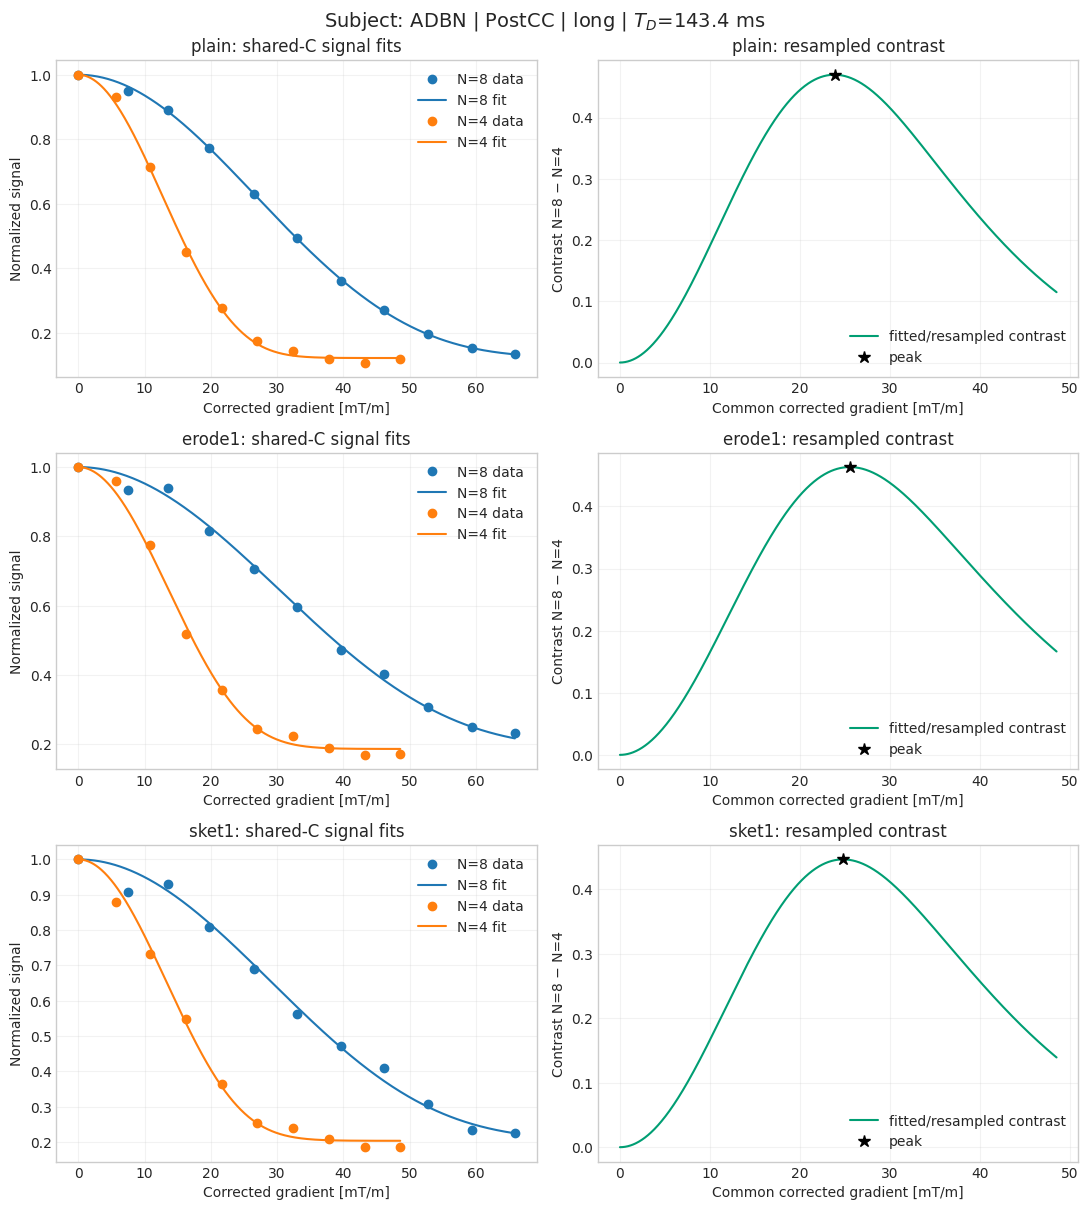

Exported 25/250 signal/contrast panels
Exported 50/250 signal/contrast panels
Exported 75/250 signal/contrast panels
Exported 100/250 signal/contrast panels
Exported 125/250 signal/contrast panels
Exported 150/250 signal/contrast panels
Exported 175/250 signal/contrast panels
Exported 200/250 signal/contrast panels
Exported 225/250 signal/contrast panels
Exported 250/250 signal/contrast panels


,subj,all_selected_variants_successful,panels
0,ADBN,True,40
1,ARVE,False,4
2,ARVE,True,36
3,BRAIN,False,4
4,BRAIN,True,46
5,LUDG,True,40
6,MBBL,True,40
7,SNVN,True,40


Exhaustive Section 6 gallery: /mnt/d/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup/06_all_signal_contrast_panels
Gallery panels: 250


In [29]:
figure_1b = plot_signal_contrast_example(
    masters,
    contrasts,
    contrast_fits,
    variants=selected_variants,
    subject=EXAMPLE_SUBJECT,
    roi=EXAMPLE_ROI,
    direction=EXAMPLE_DIRECTION,
    td_ms=EXAMPLE_TD_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    gradient_column=GRADIENT_COLUMN,
    output_path=OUTPUT_DIR / '01_signal_and_contrast.png' if SAVE_OUTPUTS else None,
)
plt.show()

all_panel_manifest = pd.DataFrame()
if SAVE_OUTPUTS and EXPORT_ALL_SIGNAL_CONTRAST_PANELS:
    all_panel_dir = OUTPUT_DIR / '06_all_signal_contrast_panels'
    all_panel_manifest = export_all_signal_contrast_panels(
        masters,
        contrasts,
        contrast_fits,
        variants=selected_variants,
        output_dir=all_panel_dir,
        n_high=N_HIGH,
        n_low=N_LOW,
        gradient_column=GRADIENT_COLUMN,
        dpi=BATCH_PANEL_DPI,
        progress_every=BATCH_PROGRESS_EVERY,
        clean_output=CLEAN_BATCH_PANEL_DIR,
    )
    display(
        all_panel_manifest.groupby(
            ['subj', 'all_selected_variants_successful'], as_index=False
        ).size().rename(columns={'size': 'panels'})
    )
    print(f'Exhaustive Section 6 gallery: {all_panel_dir}')
    print(f'Gallery panels: {len(all_panel_manifest):,}')

## 7. Figure 2 analogue: contrast versus filtered length

Rows are ROI variants and columns are fiber-relative directions. Each colored line is one diffusion time. It is the same resampled contrast from Section 6, re-parameterized from corrected gradient to the historical Capiglioni center filter length $l_{cf}$; it is not a second contrast fit. The x-axis limits reproduce the abstract range and are presentation controls only.

Insets show $\tau_{f,\mathrm{peak}}$ versus $T_D$: points are the peak-derived values and the black line is the pseudo-Huber model with fixed PGSE $\alpha$. This panel connects the two scales of the analysis: the main axes show where contrast is generated in filter-length space, while the inset summarizes how the peak-defined time evolves with diffusion time. Compare peak position and shape across variants, but also inspect fit QC before assigning a biological meaning to a visual shift.

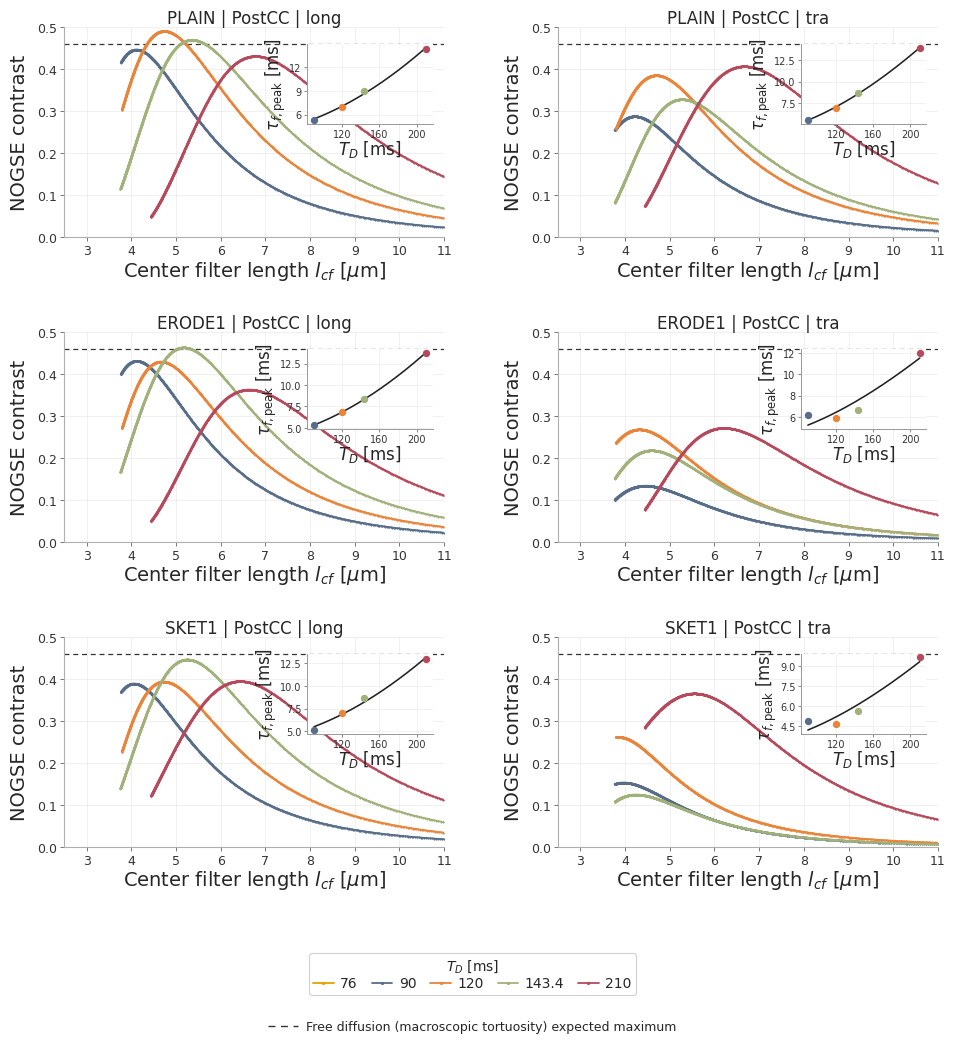

Exported 25/30 contrast-versus-filtered-length panels
Exported 30/30 contrast-versus-filtered-length panels


,subj,all_selected_variants_successful,ROI panels
0,ADBN,True,5
1,ARVE,True,5
2,BRAIN,True,5
3,LUDG,True,5
4,MBBL,True,5
5,SNVN,True,5


Figure-02 gallery: /mnt/d/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup/02_all_contrast_vs_filtered_length
Gallery panels: 30


In [30]:
figure_2 = plot_contrast_lcf_grid(
    contrasts,
    contrast_fits,
    tc_data,
    tc_summary,
    variants=selected_variants,
    subject=EXAMPLE_SUBJECT,
    roi=EXAMPLE_ROI,
    directions=analysis_directions,
    lcf_limits_um=LCF_LIMITS_UM,
    td_color_tolerance_ms=TD_COLOR_TOLERANCE_MS,
    output_path=OUTPUT_DIR / '02_contrast_vs_filtered_length.png' if SAVE_OUTPUTS else None,
)
plt.show()

all_lcf_panel_manifest = pd.DataFrame()
if SAVE_OUTPUTS and EXPORT_ALL_CONTRAST_LCF_PANELS:
    all_lcf_panel_dir = OUTPUT_DIR / '02_all_contrast_vs_filtered_length'
    all_lcf_panel_manifest = export_all_contrast_lcf_panels(
        contrasts,
        contrast_fits,
        tc_data,
        tc_summary,
        variants=selected_variants,
        directions=analysis_directions,
        output_dir=all_lcf_panel_dir,
        lcf_limits_um=LCF_LIMITS_UM,
        td_color_tolerance_ms=TD_COLOR_TOLERANCE_MS,
        dpi=BATCH_PANEL_DPI,
        progress_every=BATCH_PROGRESS_EVERY,
        clean_output=CLEAN_BATCH_PANEL_DIR,
    )
    display(
        all_lcf_panel_manifest.groupby(
            ['subj', 'all_selected_variants_successful'], as_index=False
        ).size().rename(columns={'size': 'ROI panels'})
    )
    print(f'Figure-02 gallery: {all_lcf_panel_dir}')
    print(f'Gallery panels: {len(all_lcf_panel_manifest):,}')

## 8. Figure 3 analogue: regional $\delta$ and $\alpha$

The upper row shows the NOGSE-derived transition time $\delta$; the lower row shows the independent PGSE-derived $\alpha_{macro}$. Bars are arithmetic means across the valid subjects in each ROI/variant/direction cell and error bars are the standard error of that mean. Open markers retain every subject-level estimate, so the reader can distinguish a consistent variant shift from a bar driven by one subject.

All variants share axes within each direction. Only `presentation_ok` transition fits enter this figure, but the exclusion tables remain part of the output. A missing marker is missing/invalid data, not a zero. Because the valid subject count may differ after ROI loss or fit exclusion, paired differences in Section 10 are the correct basis for quantitative claims about segmentation effects.

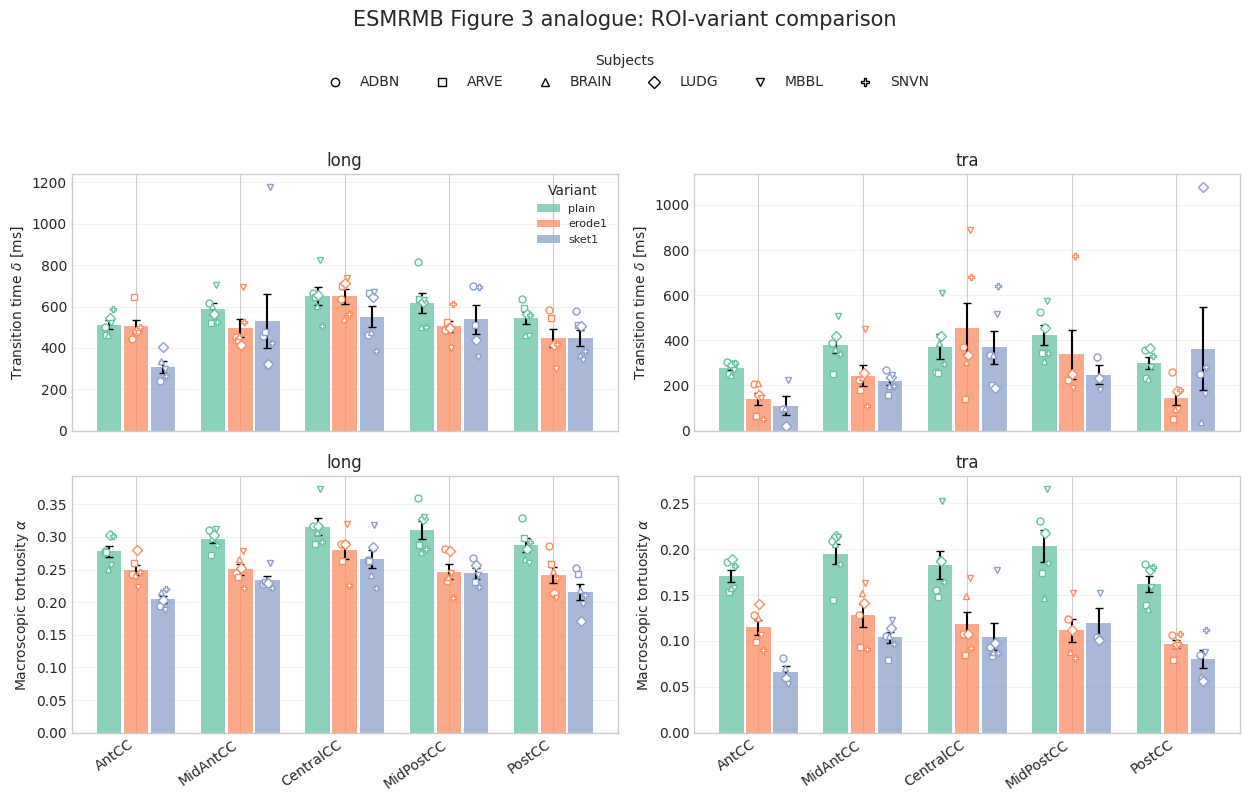

In [31]:
figure_3 = plot_metric_comparison(
    metrics_for_plots,
    variants=selected_variants,
    rois=analysis_rois,
    directions=analysis_directions,
    output_path=OUTPUT_DIR / '03_delta_alpha_by_region.png' if SAVE_OUTPUTS else None,
)
plt.show()

## 9. Figure 4 analogue: $\delta$ versus $\alpha$

Every point is one matched subject/ROI/direction estimate: x is the PGSE-derived $\alpha_{macro}$ and y is the NOGSE-derived transition time $\delta$. Color identifies the ROI and marker shape identifies the subject. Separate variant-by-direction panels prevent a change in ROI extraction from being hidden by overplotting.

This figure is descriptive: it shows clustering, outliers, subject consistency, and possible association between the two observables. It does not by itself establish correlation or causality. Any formal association should account for repeated measurements within subject, ROI, direction, and variant instead of treating all points as independent.

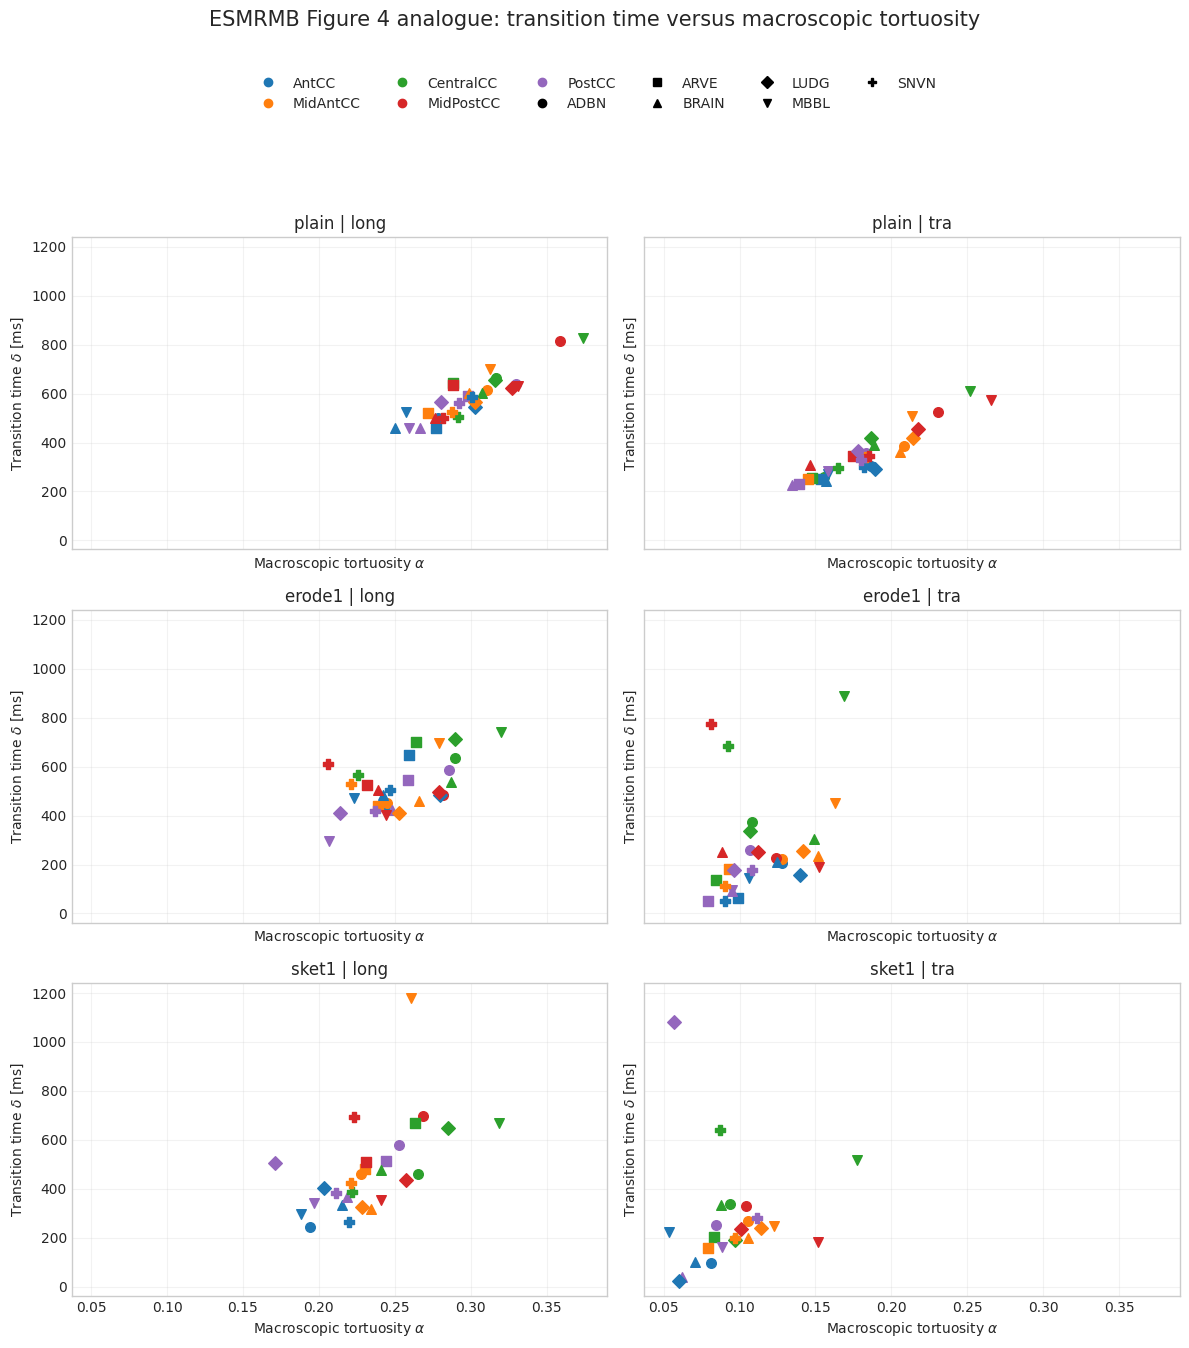

In [32]:
figure_4 = plot_alpha_delta_scatter(
    metrics_for_plots,
    variants=selected_variants,
    rois=analysis_rois,
    directions=analysis_directions,
    output_path=OUTPUT_DIR / '04_alpha_vs_delta.png' if SAVE_OUTPUTS else None,
)
plt.show()

## 10. Paired variant effects and export

Only matched subject/ROI/direction combinations enter paired differences. For metric $x$, the exported definitions are

$$\Delta x=x_{variant}-x_{reference}, \qquad \Delta x[\%]=100\frac{x_{variant}-x_{reference}}{x_{reference}}.$$

This pairing removes between-subject and between-ROI level differences from the segmentation comparison. Missing ROIs or invalid fits are never imputed, and the matched-case count is reported beside every mean difference. Percent differences can become unstable when the reference is near zero, so absolute and relative effects should be read together. These summaries are descriptive and do not replace a repeated-measures statistical model if inferential claims are required.

In [33]:
variant_differences = compare_with_reference_metrics(
    metrics_for_plots,
    reference_variant=REFERENCE_VARIANT,
)
variant_differences.insert(0, 'dataset', DATASET)
difference_summary = (
    variant_differences.groupby(['variant', 'direction'], as_index=False)
    .agg(
        matched_cases=('subj', 'size'),
        alpha_mean_difference=('alpha_macro_difference', 'mean'),
        alpha_mean_percent_difference=('alpha_macro_percent_difference', 'mean'),
        delta_mean_difference_ms=('delta_ms_difference', 'mean'),
        delta_mean_percent_difference=('delta_ms_percent_difference', 'mean'),
    )
)
difference_summary.insert(0, 'dataset', DATASET)
analysis_config = pd.DataFrame(
    [{
        'dataset': DATASET,
        'sequence': SEQUENCE,
        'dwi_level': DWI_LEVEL,
        'variants': ';'.join(selected_variants),
        'reference_variant': REFERENCE_VARIANT,
        'rois': ';'.join(analysis_rois),
        'directions': ';'.join(analysis_directions),
        'N_high': N_HIGH,
        'N_low': N_LOW,
        'D0_reference_m2_ms': D0_REFERENCE_M2_MS,
        'D0_reference_mm2_s': D0_REFERENCE_M2_MS * 1e9,
        'gradient_column': GRADIENT_COLUMN,
        'lcf_convention': 'capiglioni_2021',
        'lcf_definition': 'sqrt(D0 * tau_f)',
        'td_color_tolerance_ms': TD_COLOR_TOLERANCE_MS,
        'bvalue_column': 'bvalue_g',
        'gradient_correction': APPLY_GRADIENT_CORRECTION,
        'contrast_construction': 'restricted_signal_fits_shared_C_resampled_common_gradient',
        'resample_grid_size': RESAMPLE_GRID_SIZE,
        'signal_tc_bounds_ms': ';'.join(map(str, SIGNAL_TC_BOUNDS_MS)),
        'rician_C_bounds': ';'.join(map(str, RICIAN_C_BOUNDS)),
        'excluded_td_ms': ';'.join(map(str, EXCLUDE_TD_MS)),
        'td_min_ms': TD_RANGE_MS[0],
        'td_max_ms': TD_RANGE_MS[1],
        'minimum_pseudohuber_r2': MIN_PSEUDOHUBER_R2_FOR_SUMMARY,
        'exclude_delta_boundary': EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY,
        'export_all_signal_contrast_panels': EXPORT_ALL_SIGNAL_CONTRAST_PANELS,
        'export_all_contrast_lcf_panels': EXPORT_ALL_CONTRAST_LCF_PANELS,
        'clean_batch_panel_dir': CLEAN_BATCH_PANEL_DIR,
        'batch_panel_dpi': BATCH_PANEL_DPI,
        'figure_formats': 'png;pdf',
        'batch_panel_key': 'subj;sheet;roi;direction;td_ms',
        'contrast_lcf_panel_key': 'subj;roi',
    }]
)
display(difference_summary)

,dataset,variant,direction,matched_cases,alpha_mean_difference,alpha_mean_percent_difference,delta_mean_difference_ms,delta_mean_percent_difference
0,brains,erode1,long,30,-0.044396,-14.804189,-62.276926,-9.818268
1,brains,erode1,tra,29,-0.069190,-37.677229,-89.801913,-26.853025
2,brains,plain,long,30,0.000000,0.000000,0.000000,0.000000
3,brains,plain,tra,30,0.000000,0.000000,0.000000,0.000000
4,brains,sket1,long,28,-0.066029,-22.093852,-111.462080,-19.722590
5,brains,sket1,tra,24,-0.092900,-49.894692,-91.655426,-24.015160


In [34]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    analysis_config.to_csv(OUTPUT_DIR / 'analysis_config.csv', index=False)
    qc.to_csv(OUTPUT_DIR / 'master_qc.csv', index=False)
    coverage.to_csv(OUTPUT_DIR / 'coverage_vs_reference.csv', index=False)
    missing_rows.to_csv(OUTPUT_DIR / 'missing_master_rows.csv', index=False)
    contrasts.to_csv(OUTPUT_DIR / 'resampled_contrast.csv', index=False)
    contrast_fits.to_csv(OUTPUT_DIR / 'signal_pair_fit_summary.csv', index=False)
    contrast_shape.to_csv(OUTPUT_DIR / 'contrast_shape_metrics.csv', index=False)
    tc_data.rename(columns={'tc_peak_ms': 'tau_f_peak_ms', 'tc_peak_std_ms': 'tau_f_peak_std_ms'}).to_csv(
        OUTPUT_DIR / 'tau_f_peak_vs_td.csv', index=False
    )
    tc_data.to_csv(OUTPUT_DIR / 'tc_peak_vs_td.csv', index=False)
    tc_summary.to_csv(OUTPUT_DIR / 'pseudohuber_fit_summary.csv', index=False)
    fit_exclusions.to_csv(OUTPUT_DIR / 'pseudohuber_fit_exclusions.csv', index=False)
    metrics.to_csv(OUTPUT_DIR / 'alpha_delta_subject_summary.csv', index=False)
    variant_differences.to_csv(OUTPUT_DIR / 'variant_differences_vs_reference.csv', index=False)
    difference_summary.to_csv(OUTPUT_DIR / 'variant_difference_summary.csv', index=False)
    print(f'Figures and audit tables saved under: {OUTPUT_DIR}')

Figures and audit tables saved under: /mnt/d/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup


## 11. Phantom-to-phantom and brain-to-phantom comparison

This section is independent of the single-dataset/variant workflow above. It loads both available phantom acquisitions, compares `20220610P` with `20260706P`, and then compares a selectable phantom (default `20260706P`) with a selectable brain ROI variant (default `plain`). The phantom analysis uses the available `den_gr` and `den_gr-topup` products rather than pretending that the two acquisitions are segmentation variants.

Legacy phantom alpha workbooks may have been generated with the brain reference diffusivity (0.0032 mm$^2$/s). The pipeline now uses 0.0023 mm$^2$/s for phantoms, and this notebook independently audits and harmonizes loaded alpha values from their stored `D0_mean_mm2_s`. When direct rotated and legacy reconstructed `long`/`tra` rows coexist, the direct rotated row is retained. Any harmonization is recorded in the exported tables.

The primary alternatives to the peak-only metric use the entire positive contrast curve: normalized-gradient area, centroid and spread, plus a log-length centroid and geometric width. These are descriptive observables, not additional independent samples. The historical peak and pseudo-Huber results remain available as sensitivity analyses.

In [35]:
# Cross-dataset selection. This is separate from the main selection in Section 2.
# Paths for known phantoms; edit only when a new processed phantom is added.
PHANTOM_RUN_CONFIG = {
    '20220610P': {'dwi_level': 'den_gr', 'variant': 'manual'},
    '20260706P': {'dwi_level': 'den_gr-topup', 'variant': 'manual'},
}
# Include both IDs for the phantom-to-phantom plots, or one ID to inspect one phantom.
PHANTOM_IDS = ['20220610P', '20260706P']
# Brain source/segmentation. Try 'erode1' or 'sket1' for sensitivity analyses.
BRAIN_DWI_LEVEL = 'den_gr-topup'
BRAIN_VARIANT = 'plain'
# None uses all brains; a list restricts the complete cross-dataset analysis.
BRAIN_SUBJECTS = None              # e.g. ['ADBN'] or ['ADBN', 'ARVE']
# Choose which loaded phantom is placed beside brains in Sections 11.3-11.4.
BRAIN_COMPARISON_PHANTOM = '20220610P'
PHANTOM_D0_M2_MS = 2.3e-12  # 0.0023 mm2/s
BRAIN_D0_M2_MS = 3.2e-12    # 0.0032 mm2/s
# Phantom ROIs used in the cross-cohort figures; water remains an alpha reference.
CROSS_COMPARISON_ROIS = ['fiber1', 'fiber2']
RUN_SHARED_TC_SENSITIVITY = True   # False makes Section 11 faster but skips model audit
CROSS_OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / 'esmrmb_variant_comparison' / 'cross_dataset'

if BRAIN_COMPARISON_PHANTOM not in PHANTOM_IDS:
    raise ValueError('BRAIN_COMPARISON_PHANTOM must be one of PHANTOM_IDS.')


In [36]:
def run_domain_analysis(
    dataset, dwi_level, variant, d0_m2_ms, rois, internal_reference_rois, subjects=None
):
    domain_runs = discover_analysis_runs(
        PROJECT_ROOT, dataset=dataset, sequence='ogse', dwi_level=dwi_level
    )
    domain_master = load_masters(domain_runs, [variant])
    domain_alpha_raw = load_alpha_summaries(
        domain_runs, [variant], reference_d0_m2_ms=d0_m2_ms
    )
    if subjects is not None:
        domain_master = domain_master[domain_master['subj'].isin(subjects)].copy()
        domain_alpha_raw = domain_alpha_raw[domain_alpha_raw['subj'].isin(subjects)].copy()
    domain_alpha_internal = normalize_alpha_to_internal_reference(
        domain_alpha_raw, reference_rois=internal_reference_rois
    )
    internal_keys = ['variant', 'subj', 'roi', 'direction']
    domain_alpha_internal = domain_alpha_internal.groupby(internal_keys, as_index=False).agg(
        alpha_internal=('alpha_internal', 'mean'),
        alpha_internal_error=('alpha_internal_error', lambda x: (np.sqrt(np.nansum(x**2)) / x.notna().sum()) if x.notna().any() else np.nan),
        internal_reference_D0_mm2_s=('internal_reference_D0_mm2_s', 'mean'),
    )
    domain_alpha = aggregate_alpha(domain_alpha_raw)
    separate_contrast, separate_fits = build_resampled_contrasts(
        domain_master, d0_m2_ms=d0_m2_ms, n_high=N_HIGH, n_low=N_LOW,
        directions=['long', 'tra'], rois=rois,
        gradient_column=GRADIENT_COLUMN,
        apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
        tc_bounds_ms=SIGNAL_TC_BOUNDS_MS, rician_c_bounds=RICIAN_C_BOUNDS,
        grid_size=RESAMPLE_GRID_SIZE, tc_mode='separate',
    )
    shape = summarize_contrast_shape(separate_contrast)
    shared_fits = pd.DataFrame()
    if RUN_SHARED_TC_SENSITIVITY:
        _, shared_fits = build_resampled_contrasts(
            domain_master, d0_m2_ms=d0_m2_ms, n_high=N_HIGH, n_low=N_LOW,
            directions=['long', 'tra'], rois=rois,
            gradient_column=GRADIENT_COLUMN,
            apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
            tc_bounds_ms=SIGNAL_TC_BOUNDS_MS, rician_c_bounds=RICIAN_C_BOUNDS,
            grid_size=128, tc_mode='shared',
        )
    return {
        'runs': domain_runs, 'master': domain_master, 'alpha': domain_alpha,
        'alpha_internal': domain_alpha_internal,
        'contrast': separate_contrast, 'fits': separate_fits,
        'shape': shape, 'shared_fits': shared_fits,
    }

phantom_results = {}
for phantom_id in PHANTOM_IDS:
    config = PHANTOM_RUN_CONFIG[phantom_id]
    result = run_domain_analysis(
        'phantoms', config['dwi_level'], config['variant'],
        PHANTOM_D0_M2_MS, CROSS_COMPARISON_ROIS,
        ['water', 'water1', 'water2', 'water3'], [phantom_id],
    )
    for name in ['master', 'alpha', 'alpha_internal', 'contrast', 'fits', 'shape', 'shared_fits']:
        if not result[name].empty:
            result[name].insert(0, 'cohort', phantom_id)
    phantom_results[phantom_id] = result

brain_result = run_domain_analysis(
    'brains', BRAIN_DWI_LEVEL, BRAIN_VARIANT, BRAIN_D0_M2_MS,
    list(CC_ROIS), ['Left-Lateral-Ventricle', 'Right-Lateral-Ventricle'], BRAIN_SUBJECTS,
)
for name in ['master', 'alpha', 'alpha_internal', 'contrast', 'fits', 'shape', 'shared_fits']:
    if not brain_result[name].empty:
        brain_result[name].insert(0, 'cohort', 'brains')

phantom_shape = pd.concat([result['shape'] for result in phantom_results.values()], ignore_index=True)
phantom_alpha = pd.concat([result['alpha'] for result in phantom_results.values()], ignore_index=True)
phantom_alpha_internal = pd.concat(
    [result['alpha_internal'] for result in phantom_results.values()], ignore_index=True
)
display(phantom_shape.groupby(['cohort', 'roi', 'direction']).size().rename('curves').reset_index())


,cohort,roi,direction,curves
0,20220610P,fiber1,long,5
1,20220610P,fiber1,tra,5
2,20220610P,fiber2,long,5
3,20220610P,fiber2,tra,5
4,20260706P,fiber1,long,4
5,20260706P,fiber1,tra,4
6,20260706P,fiber2,long,4
7,20260706P,fiber2,tra,4


### 11.1 Model adequacy and peak identifiability

A shared effective $\tau_c$ is the physically constrained version of the single-restriction model; the separate-$\tau_c$ fit is retained only as a flexible interpolator for constructing a smooth contrast. BIC compares these nested descriptions per signal pair. Strong preference for separate $\tau_c$ indicates model mismatch or heterogeneous dynamics, not evidence that the tissue has two encoding-specific correlation times. A peak at the supported-gradient boundary is not an identified interior maximum and must not be converted into a microstructural time.

In [37]:
def compare_tc_parameterizations(result):
    if result['shared_fits'].empty:
        return pd.DataFrame()
    keys = ['cohort', 'subj', 'sheet', 'roi', 'direction', 'td_ms']
    shared = result['shared_fits'][keys + ['ok', 'r2', 'rmse', 'bic', 'tc_shared_ms', 'peak_at_boundary']]
    separate = result['fits'][keys + ['ok', 'r2', 'rmse', 'bic', 'tc_high_ms', 'tc_low_ms', 'peak_at_boundary']]
    table = shared.merge(separate, on=keys, suffixes=('_shared', '_separate'), validate='one_to_one')
    table['delta_bic_shared_minus_separate'] = table['bic_shared'] - table['bic_separate']
    table['bic_preference'] = np.select(
        [table['delta_bic_shared_minus_separate'] < -6, table['delta_bic_shared_minus_separate'] > 6],
        ['shared', 'separate'], default='inconclusive',
    )
    return table

all_domain_masters = pd.concat(
    [*[result['master'] for result in phantom_results.values()], brain_result['master']],
    ignore_index=True,
)
protocol_rows = all_domain_masters[
    all_domain_masters['row_kind'].eq('signal_rotated')
    & all_domain_masters['stat'].eq('avg')
    & pd.to_numeric(all_domain_masters['N'], errors='coerce').isin([N_HIGH, N_LOW])
].copy()
protocol_audit = protocol_rows.groupby(
    ['cohort', 'subj', 'sheet', 'td_ms', 'N'], as_index=False
).agg(TE_ms=('TE', 'median'), TR_ms=('TR', 'median'), g_max_mTm=('g_max', 'max'))
protocol_audit = protocol_audit.pivot(
    index=['cohort', 'subj', 'sheet', 'td_ms'], columns='N',
    values=['TE_ms', 'TR_ms', 'g_max_mTm'],
).reset_index()
protocol_audit.columns = [
    '_'.join(str(part) for part in column if str(part) != '').rstrip('_')
    if isinstance(column, tuple) else str(column) for column in protocol_audit.columns
]
protocol_audit['TE_difference_high_minus_low_ms'] = (
    protocol_audit[f'TE_ms_{N_HIGH}'] - protocol_audit[f'TE_ms_{N_LOW}']
)
display(protocol_audit)

model_audit = pd.concat(
    [compare_tc_parameterizations(result) for result in [*phantom_results.values(), brain_result]],
    ignore_index=True,
)
model_audit_summary = model_audit.groupby('cohort', as_index=False).agg(
    signal_pairs=('subj', 'size'),
    shared_median_r2=('r2_shared', 'median'),
    separate_median_r2=('r2_separate', 'median'),
    strong_separate_fraction=('bic_preference', lambda x: (x == 'separate').mean()),
    separate_peak_boundary_fraction=('peak_at_boundary_separate', 'mean'),
)
display(model_audit_summary)


,cohort,subj,sheet,td_ms,TE_ms_4,TE_ms_8,TR_ms_4,TR_ms_8,g_max_mTm_4,g_max_mTm_8,TE_difference_high_minus_low_ms
0,20220610P,20220610P,20220610-PHANTOM3,75.1,98.0,98.0,2000.0,2000.0,75.402299,73.840415,0.0
1,20220610P,20220610P,20220610-PHANTOM3,97.1,120.0,120.0,2000.0,2000.0,76.404652,75.872026,0.0
2,20220610P,20220610P,20220610-PHANTOM3,119.1,142.0,142.0,2000.0,2000.0,69.393919,75.612415,0.0
3,20220610P,20220610P,20220610-PHANTOM3,142.5,166.0,166.0,2000.0,2000.0,47.789819,73.618657,0.0
4,20220610P,20220610P,20220610-PHANTOM3,209.1,232.0,232.0,2000.0,2000.0,25.961106,52.382094,0.0
5,20260706P,20260706P,20260706_OGSETEST,90.0,117.0,117.0,6000.0,6000.0,76.404652,75.872026,0.0
6,20260706P,20260706P,20260706_OGSETEST,120.0,142.0,142.0,6200.0,6200.0,69.689844,75.612415,0.0
7,20260706P,20260706P,20260706_OGSETEST,143.4,165.0,165.0,6900.0,6900.0,54.488777,73.933941,0.0
8,20260706P,20260706P,20260706_OGSETEST,210.0,267.0,228.0,9900.0,8800.0,31.180358,51.523854,-39.0
9,brains,ADBN,20260710_ADBN-1,90.0,117.0,117.0,6000.0,6000.0,76.404652,75.872026,0.0


,cohort,signal_pairs,shared_median_r2,separate_median_r2,strong_separate_fraction,separate_peak_boundary_fraction
0,20220610P,20,0.997965,0.999312,0.550,0.2000
1,20260706P,16,0.996107,0.998874,0.875,0.0625
2,brains,250,0.970258,0.994655,0.916,0.0560


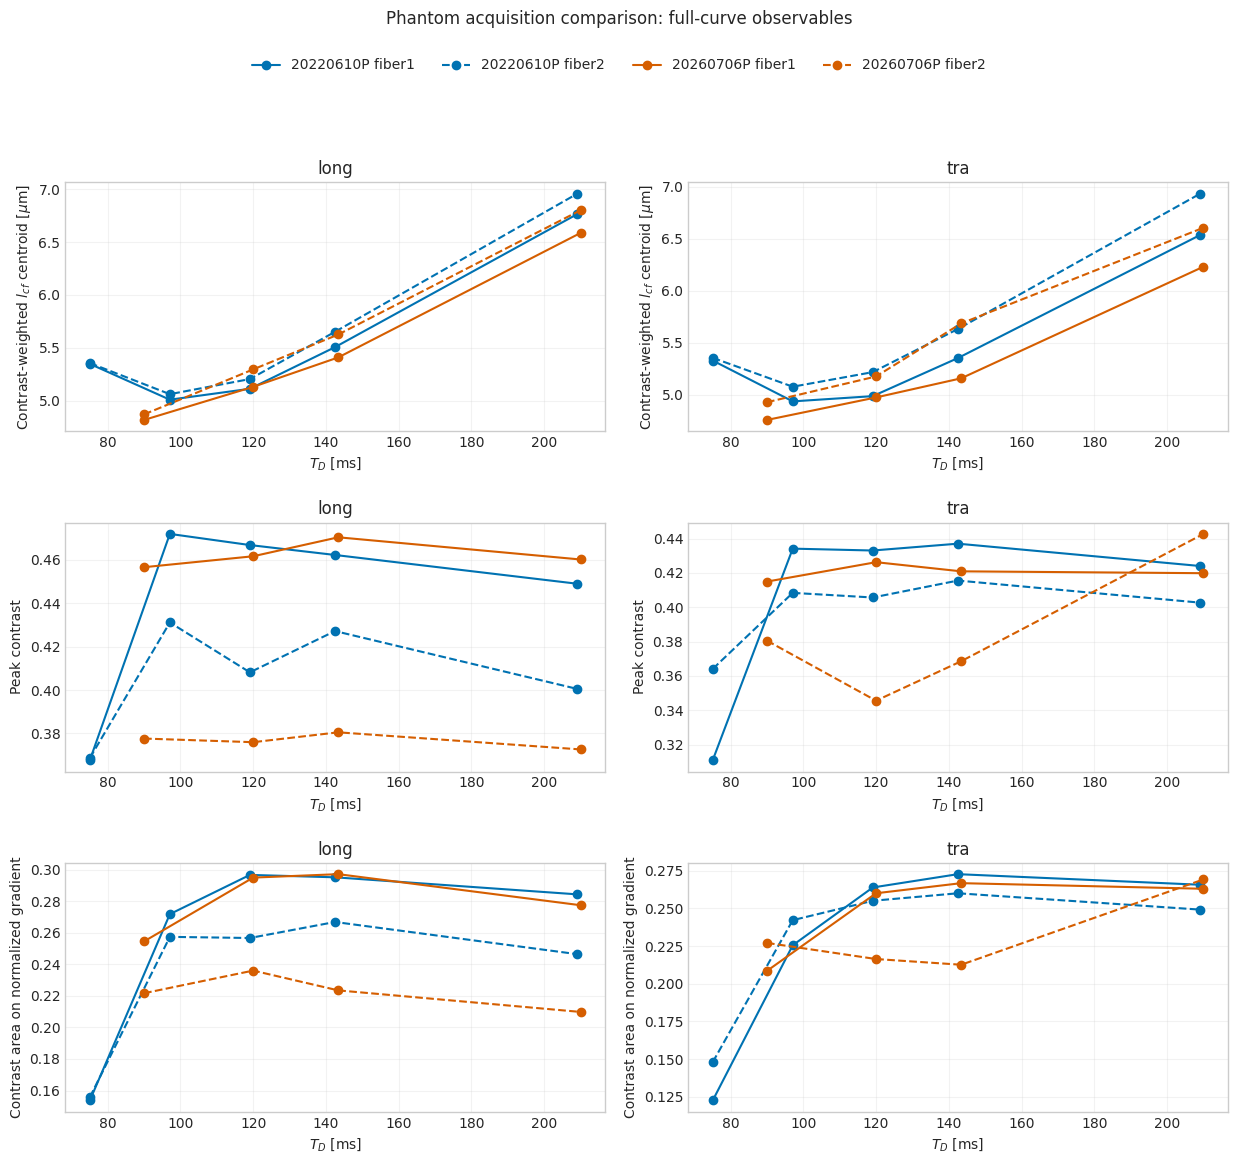

In [38]:
shape_metrics_to_plot = [
    ('lcf_centroid_um', 'Contrast-weighted $l_{cf}$ centroid [$\mu$m]'),
    ('contrast_peak', 'Peak contrast'),
    ('contrast_auc_normalized_g', 'Contrast area on normalized gradient'),
]
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=False)
colors = {'20220610P': '#0072B2', '20260706P': '#D55E00'}
linestyles = {'fiber1': '-', 'fiber2': '--'}
for row, (metric, ylabel) in enumerate(shape_metrics_to_plot):
    for col, direction in enumerate(['long', 'tra']):
        ax = axes[row, col]
        subset = phantom_shape[phantom_shape['direction'].eq(direction)]
        for (cohort, roi), group in subset.groupby(['cohort', 'roi']):
            group = group.sort_values('td_ms')
            ax.plot(group['td_ms'], group[metric], marker='o', color=colors[cohort],
                    linestyle=linestyles[roi], label=f'{cohort} {roi}')
        ax.set_title(direction)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('$T_D$ [ms]')
        ax.grid(alpha=0.25)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle('Phantom acquisition comparison: full-curve observables', y=0.985)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.955),
           ncol=4, frameon=False)
fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.90), h_pad=2.0, w_pad=2.0)
if SAVE_OUTPUTS:
    CROSS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_figure_formats(fig, CROSS_OUTPUT_DIR / '11_phantom_comparison_shape_metrics.png', dpi=300)
plt.show()


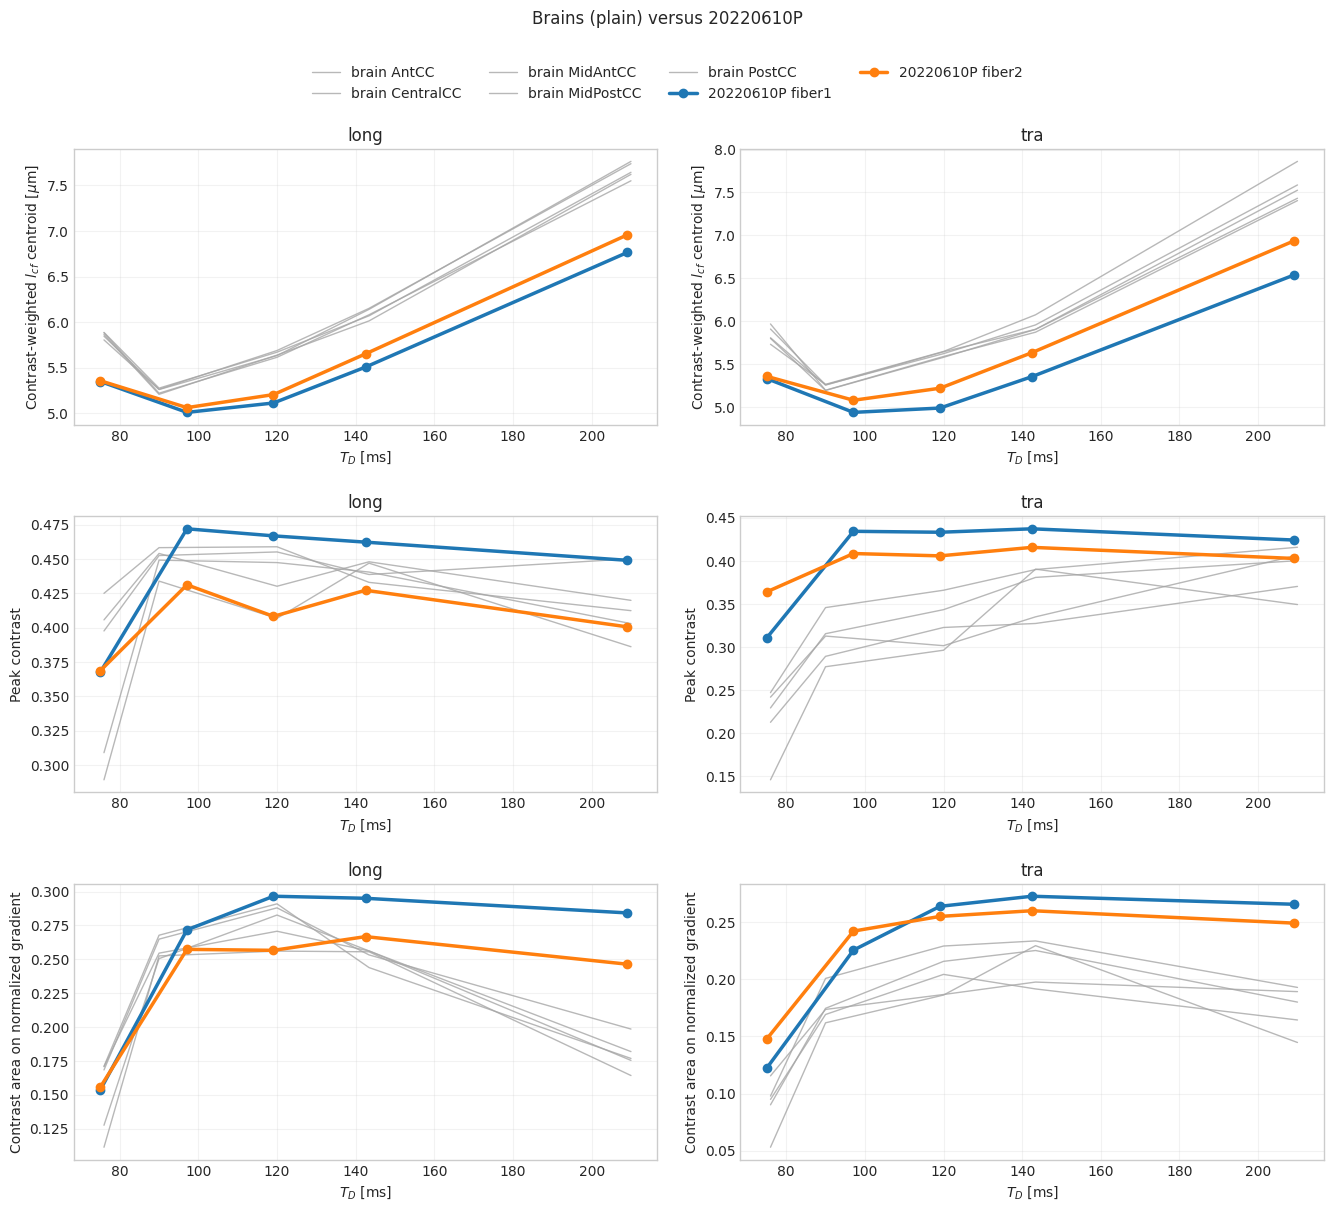

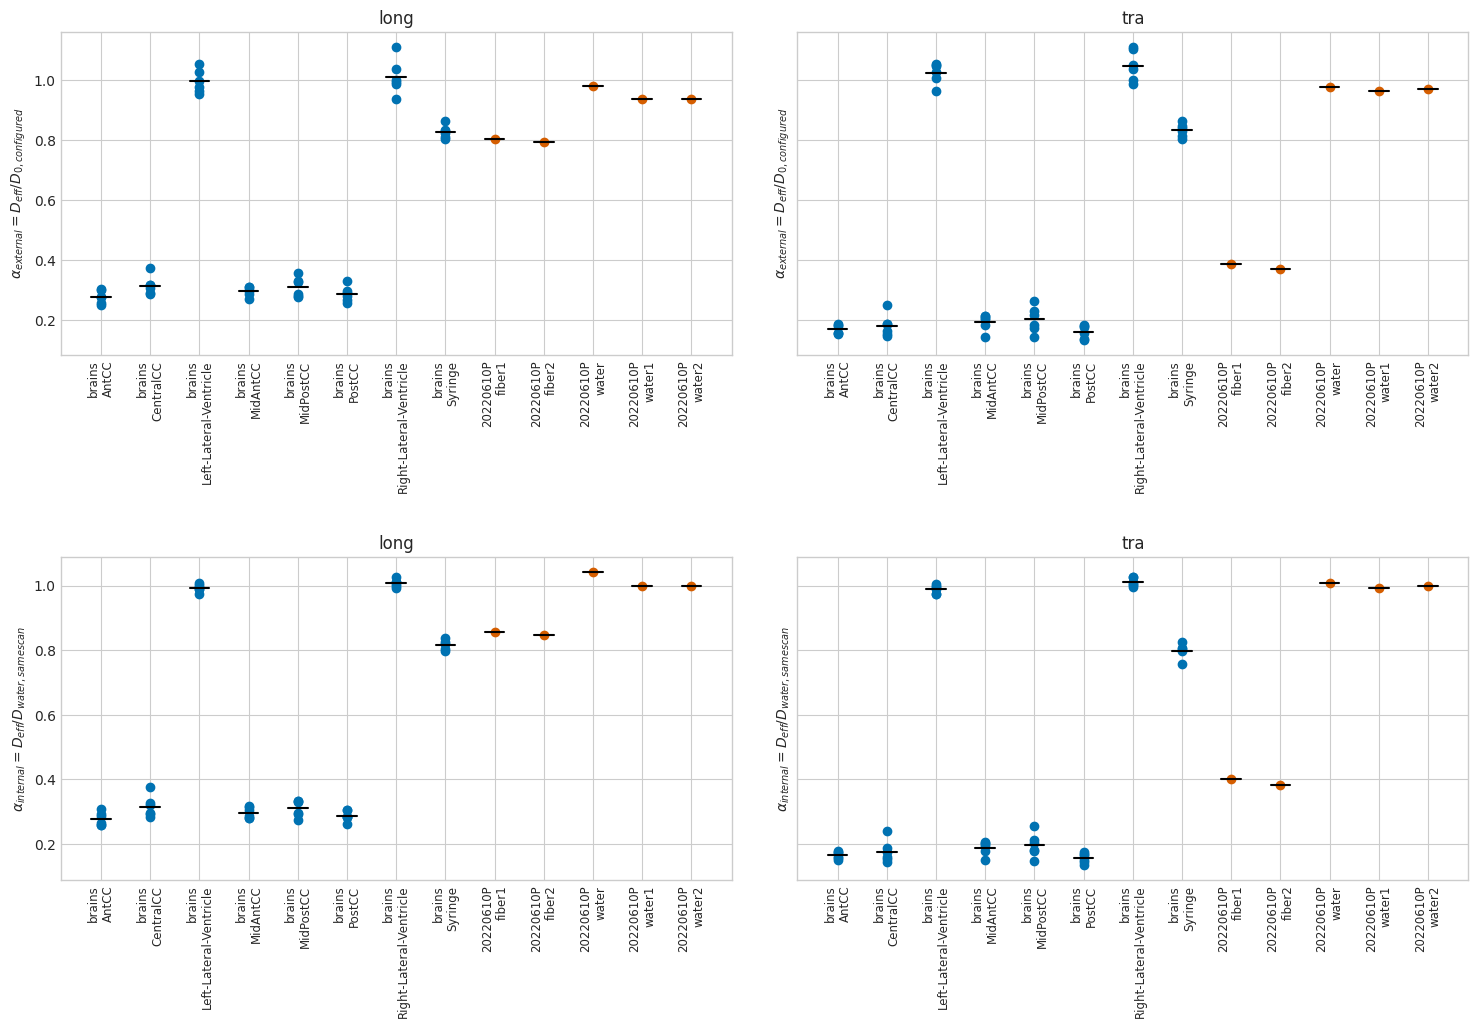

In [39]:
selected_phantom_shape = phantom_results[BRAIN_COMPARISON_PHANTOM]['shape'].copy()
brain_shape = brain_result['shape'].copy()
comparison_shape = pd.concat([brain_shape, selected_phantom_shape], ignore_index=True)
comparison_alpha = pd.concat([brain_result['alpha'], phantom_results[BRAIN_COMPARISON_PHANTOM]['alpha']], ignore_index=True)
comparison_alpha_internal = pd.concat(
    [brain_result['alpha_internal'], phantom_results[BRAIN_COMPARISON_PHANTOM]['alpha_internal']],
    ignore_index=True,
)

fig, axes = plt.subplots(3, 2, figsize=(14, 12.5))
for row, (metric, ylabel) in enumerate(shape_metrics_to_plot):
    for col, direction in enumerate(['long', 'tra']):
        ax = axes[row, col]
        brain = brain_shape[brain_shape['direction'].eq(direction)]
        brain_summary = brain.groupby(['roi', 'td_ms'], as_index=False)[metric].agg(['mean', 'sem']).reset_index()
        for roi, group in brain_summary.groupby('roi'):
            ax.plot(group['td_ms'], group['mean'], color='0.65', alpha=0.8, linewidth=1, label=f'brain {roi}')
        phantom = selected_phantom_shape[selected_phantom_shape['direction'].eq(direction)]
        for roi, group in phantom.groupby('roi'):
            group = group.sort_values('td_ms')
            ax.plot(group['td_ms'], group[metric], marker='o', linewidth=2.5,
                    label=f'{BRAIN_COMPARISON_PHANTOM} {roi}')
        ax.set_title(direction)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('$T_D$ [ms]')
        ax.grid(alpha=0.25)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(f'Brains ({BRAIN_VARIANT}) versus {BRAIN_COMPARISON_PHANTOM}', y=0.985)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95),
           ncol=4, frameon=False)
fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.93), h_pad=2.0, w_pad=2.0)
if SAVE_OUTPUTS:
    save_figure_formats(fig, CROSS_OUTPUT_DIR / '12_brain_vs_selected_phantom_shape_metrics.png', dpi=300)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10.5), sharey='row')
alpha_panels = [
    (comparison_alpha, 'alpha_macro', r'$\alpha_{external}=D_{eff}/D_{0,configured}$'),
    (comparison_alpha_internal, 'alpha_internal', r'$\alpha_{internal}=D_{eff}/D_{water,same scan}$'),
]
for row, (alpha_table, alpha_column, ylabel) in enumerate(alpha_panels):
  alpha_display = alpha_table[alpha_table['direction'].isin(['long', 'tra'])].copy()
  alpha_display['group'] = alpha_display['cohort'] + ' | ' + alpha_display['roi']
  for ax, direction in zip(axes[row], ['long', 'tra']):
    subset = alpha_display[alpha_display['direction'].eq(direction)]
    groups = list(dict.fromkeys(subset['group']))
    for index, group_name in enumerate(groups):
        values = subset.loc[subset['group'].eq(group_name), alpha_column]
        ax.scatter(np.full(len(values), index), values, color='#0072B2' if group_name.startswith('brains') else '#D55E00')
        ax.plot([index - 0.2, index + 0.2], [values.mean(), values.mean()], color='black')
    group_labels = [group.replace(' | ', '\n', 1) for group in groups]
    ax.set_xticks(range(len(groups)), group_labels, rotation=90, ha='right', va='center',
                  rotation_mode='anchor')
    ax.tick_params(axis='x', labelsize=8.5, pad=4)
    ax.set_title(direction)
    ax.set_ylabel(ylabel)
fig.tight_layout(pad=1.5, h_pad=3.0, w_pad=3.0)
if SAVE_OUTPUTS:
    save_figure_formats(fig, CROSS_OUTPUT_DIR / '13_brain_vs_selected_phantom_alpha.png', dpi=300)
plt.show()


In [40]:
if SAVE_OUTPUTS:
    CROSS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    phantom_shape.to_csv(CROSS_OUTPUT_DIR / 'phantom_shape_metrics.csv', index=False)
    phantom_alpha.to_csv(CROSS_OUTPUT_DIR / 'phantom_alpha_harmonized.csv', index=False)
    phantom_alpha_internal.to_csv(CROSS_OUTPUT_DIR / 'phantom_alpha_internal_water.csv', index=False)
    comparison_shape.to_csv(CROSS_OUTPUT_DIR / 'brain_vs_phantom_shape_metrics.csv', index=False)
    comparison_alpha.to_csv(CROSS_OUTPUT_DIR / 'brain_vs_phantom_alpha_harmonized.csv', index=False)
    comparison_alpha_internal.to_csv(CROSS_OUTPUT_DIR / 'brain_vs_phantom_alpha_internal_reference.csv', index=False)
    model_audit.to_csv(CROSS_OUTPUT_DIR / 'shared_vs_separate_tc_model_audit.csv', index=False)
    model_audit_summary.to_csv(CROSS_OUTPUT_DIR / 'shared_vs_separate_tc_model_summary.csv', index=False)
    protocol_audit.to_csv(CROSS_OUTPUT_DIR / 'protocol_compatibility_audit.csv', index=False)
    print(f'Cross-dataset tables and figures saved under: {CROSS_OUTPUT_DIR}')


Cross-dataset tables and figures saved under: /mnt/d/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/cross_dataset


## 12. Output map, interpretation, and limitations

The output root is `notebooks/outputs/esmrmb_variant_comparison/<dataset>/<dwi-level>/`. Presentation-level figures `00`–`04`, configuration, QC, fitted parameters, resampled curves, and paired differences are written directly there. The exhaustive Section 6 gallery is organized as

```text
06_all_signal_contrast_panels/
├── manifest.csv
└── sub-<subject>/
    └── sheet-<acquisition>/
        ├── roi-<ROI>__dir-<direction>__td-<time>ms.png
        └── roi-<ROI>__dir-<direction>__td-<time>ms.pdf
```

Each gallery image contains every selected ROI variant as a row and is exported as matched PNG and PDF files. `manifest.csv` is the authoritative index: it stores the exact scientific key, both relative figure paths, successful variants, missing/failed variants, and whether all selected variants were available. With cleanup enabled, rerunning removes older gallery PNGs and PDFs, its older manifest, thumbnail metadata, and obsolete empty subdirectories before regenerating them. Subject and sheet remain as directories; ROI, direction, and diffusion time are encoded in the filename to keep the gallery shallow.

The Figure-02-style gallery is generated separately as:

```text
02_all_contrast_vs_filtered_length/
├── manifest.csv
└── sub-<subject>/
    ├── roi-<ROI>__contrast-vs-filtered-length.png
    └── roi-<ROI>__contrast-vs-filtered-length.pdf
```

Each of these images contains every selected ROI variant as a row, every selected direction as a column, and all available diffusion times as colored curves. It is regenerated by `Run All` when `SAVE_OUTPUTS` and `EXPORT_ALL_CONTRAST_LCF_PANELS` are both `True`.

Before using the results in a presentation:

- Report the coverage audit and any ROI/acquisition combinations missing from a variant. A segmentation that removes an ROI changes the estimand and the matched sample.
- Inspect Section 6 curves, especially low branch-specific $R^2$, a shared $C$ at its bound, a peak at the grid boundary, or obvious systematic residuals. The resampled grid makes a continuous comparison possible but does not create new experimental information.
- Inspect all pseudo-Huber exclusions and boundary fits; optimizer convergence alone is not biological validity, and $\delta$ may be weakly identified when the measured $T_D$ range does not span the crossover.
- Base segmentation-effect claims on `variant_differences_vs_reference.csv`, which contains matched cases, and always report the matched-case count. Group bars with different valid subjects are descriptive.
- Keep the dataset-specific $D_0$, gradient calibration, N pair, time exclusions, bounds, directions, and ROI definitions with the exported figures. Changing any of them changes the analysis definition.
- Treat $l_{cf}$, $\tau_{f,\mathrm{peak}}$, $\alpha$, and $\delta$ as model-dependent observables. Their uncertainty includes more than the local optimizer covariance: segmentation, calibration, model mismatch, fixed $D_0$, finite gradient sampling, and repeated measurements can all contribute.
- Do not interpret brain-versus-phantom differences as tissue effects until acquisition protocols, temperature/reference diffusivity, ROI definitions, direction conventions, and available diffusion times are demonstrably comparable.

Brain and phantom runs are written to separate dataset/DWI-level directories with compatible schemas. After the phantom master and alpha-summary tables exist, set `DATASET='phantoms'`, review its profile constants and dimensions, and rerun from the top. No contrast or fit logic needs to change.